## Limpieza de datos


In [4]:
import pandas as pd
import numpy as np



archivo = r"C:\Users\andre\OneDrive\cosas de la universidad\Uniandes\VIII\Analitica comp\Proyecto\proyecto1-secop-agencia-logistica\02-ingenieria-datos\SECOP_II_-_Contratos_Electrónicos_20260912.csv"

df = pd.read_csv(archivo)
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 8,051 | Columnas: 85


,Nombre Entidad,Nit Entidad,Departamento,Ciudad,Localización,Orden,Sector,Rama,Entidad Centralizada,Proceso de Compra,...,Número de documento Ordenador del gasto,Nombre supervisor,Tipo de documento supervisor,Número de documento supervisor,Nombre Ordenador de Pago,Tipo de documento Ordenador de Pago,Número de documento Ordenador de Pago,Documentos Tipo,Descripcion Documentos Tipo,Dirección de ejecución del contrato
0,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,899.999.162,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,defensa,Ejecutivo,Centralizada,CO1.BDOS.10448103,...,74083888,Luis Alberto Montealegre Castro,Cédula de Ciudadanía,1014237586,No definido,No definido,No definido,No,No definido,calle 14 sur N° 11-295 URB. EL PROGRESO VIA BR...
1,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,899.999.162,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,defensa,Ejecutivo,Centralizada,CO1.BDOS.457665,...,No definido,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido,CALLE 95 13-08\nDistrito Capital de Bogotá\nCO...
2,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,899.999.162,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,defensa,Ejecutivo,Centralizada,CO1.BDOS.2013851,...,91067370,Julian Almeciga,Cédula de Ciudadanía,1013599327,No definido,No definido,No definido,No,No definido,DEPARTAMENTO DE BUCEO Y SALVAMENTO AV. SN MART...
3,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,899.999.162,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,defensa,Ejecutivo,Centralizada,CO1.BDOS.8720928,...,79415117,LUIS MIGUEL POLO ACOSTA,Cédula de Ciudadanía,8786297,RICARDO JEREZ SOTO,Cédula de Ciudadanía,79415117,No,No definido,Calle 30 Vía a Malambo; al lado del Batallón V...
4,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,899.999.162,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Nacional,defensa,Ejecutivo,Centralizada,CO1.BDOS.1601337,...,19462097,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido,CALLE 95 No. 13-08\nBogotá\nDistrito Capital d...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8051 entries, 0 to 8050
Data columns (total 85 columns):
 #   Column                                                                        Non-Null Count  Dtype  
---  ------                                                                        --------------  -----  
 0   Nombre Entidad                                                                8051 non-null   object 
 1   Nit Entidad                                                                   8051 non-null   object 
 2   Departamento                                                                  8051 non-null   object 
 3   Ciudad                                                                        8051 non-null   object 
 4   Localización                                                                  8051 non-null   object 
 5   Orden                                                                         8051 non-null   object 
 6   Sector                          

In [6]:
# Duplicados
print("Filas totalmente duplicadas:", df.duplicated().sum())
print("IDs de contrato duplicados:", df['ID Contrato'].duplicated().sum())

Filas totalmente duplicadas: 0
IDs de contrato duplicados: 0


In [7]:
# Nulos por columna 
nulos = df.isnull().sum().sort_values(ascending=False)
pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'nulos': nulos, 'pct_%': pct})
resumen_nulos[resumen_nulos['nulos'] > 0]


,nulos,pct_%
Fecha de notificación de prorrogación,4959,61.59
Fecha Inicio Liquidacion,2697,33.50
Fecha Fin Liquidacion,2693,33.45
Ultima Actualizacion,1221,15.17
Fecha de Firma,691,8.58
Fecha de Inicio del Contrato,508,6.31
Fecha de Fin del Contrato,203,2.52
Número de cuenta,2,0.02


In [8]:
# Columnas con un único valor 

constantes = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
print(f"{len(constantes)} columnas constantes:")
for c in constantes:
    print(f"  - {c}: {df[c].iloc[0]!r}")

16 columnas constantes:
  - Nombre Entidad: 'AGENCIA LOGISTICA DE LAS FUERZAS MILITARES'
  - Nit Entidad: '899.999.162'
  - Departamento: 'Distrito Capital de Bogotá'
  - Ciudad: 'Bogotá'
  - Localización: 'Colombia, Bogotá,  Bogotá'
  - Orden: 'Nacional'
  - Sector: 'defensa'
  - Rama: 'Ejecutivo'
  - Entidad Centralizada: 'Centralizada'
  - Reversion: 'No'
  - Valor Amortizado: '$0'
  - Puntos del Acuerdo: 'No aplica'
  - Pilares del Acuerdo: 'No aplica'
  - Sistema General de Participaciones: '$0'
  - Sistema General de Regalías: '$0'
  - Codigo Entidad: '700.985.252'


In [9]:
cols_valor = [c for c in df.columns if c.startswith('Valor') or 'Saldo' in c]
df[cols_valor].head(5)

,Valor del Contrato,Valor de pago adelantado,Valor Facturado,Valor Pendiente de Pago,Valor Pagado,Valor Amortizado,Valor Pendiente de Amortizacion,Valor Pendiente de Ejecucion,Saldo CDP,Saldo Vigencia
0,$75.000.000,$0,$0,$75.000.000,$0,$0,$0,$75.000.000,$75.000.000,0
1,$5.848.992,$0,$0,$5.848.992,$0,$0,$0,$5.848.992,$681.043.492,0
2,$1.392.300,$0,$1.392.300,$0,$1.392.300,$0,$0,$0,$2.415.585,0
3,$34.200.000,$0,$0,$34.200.000,$0,$0,$0,$34.200.000,$35.700.000,0
4,$11.496.000.000,$0,$0,$11.496.000.000,$0,$0,$0,$11.496.000.000,$6.500.000.000,4.996.000.000


In [10]:
# Formato fechas
cols_fecha = [c for c in df.columns if c.lower().startswith('fecha')]
for c in cols_fecha:
    print(c, "-", df[c].dropna().unique()[:2])

Fecha de Firma - ['07/31/2026' '08/06/2018']
Fecha de Inicio del Contrato - ['08/26/2026' '07/27/2018']
Fecha de Fin del Contrato - ['12/31/2026' '08/13/2018']
Fecha Inicio Liquidacion - ['2026 Dec 31 12:00:00 AM' '2022 Jan 11 12:00:00 AM']
Fecha Fin Liquidacion - ['2027 Apr 30 12:00:00 AM' '2022 May 11 12:00:00 AM']
Fecha de notificación de prorrogación - ['2026 Dec 21 12:00:00 AM' '2018 Aug 31 12:00:00 AM']


In [11]:
df['Duración del contrato'].value_counts().head(10)

Duración del contrato
Dia(s)         1990
No definido    1283
9 Mes(es)       332
8 Mes(es)       309
4 Mes(es)       289
10 Mes(es)      281
5 Mes(es)       267
3 Mes(es)       263
7 Mes(es)       251
6 Mes(es)       244
Name: count, dtype: int64

In [12]:
df['Estado Contrato'].value_counts()

Estado Contrato
terminado            3153
Cerrado              3128
Modificado            573
En ejecución          447
Cancelado             301
Borrador              229
enviado Proveedor     134
Aprobado               56
En aprobación          27
cedido                  2
Suspendido              1
Name: count, dtype: int64

In [13]:
df['Nombre del banco'].value_counts().head(12)

Nombre del banco
No definido           3393
BANCOLOMBIA           1037
Bancolombia            414
DAVIVIENDA             378
BANCO DE BOGOTA        356
bancolombia            264
BBVA                   240
BANCO BBVA             202
BANCO POPULAR          193
Banco Davivienda       113
BANCO DAVIVIENDA       100
BANCO DE OCCIDENTE      95
Name: count, dtype: int64

## Limpieza de datos

Estandarizar los nombres de las columnas

In [14]:
import unicodedata
import re

def a_snake_case(texto):
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('ascii')
    texto = re.sub(r'[^0-9a-zA-Z]+', '_', texto).strip('_')
    return texto.lower()

df_clean = df.copy()
mapa_columnas = {c: a_snake_case(c) for c in df_clean.columns}
df_clean = df_clean.rename(columns=mapa_columnas)
df_clean.columns.tolist()[:15]

['nombre_entidad',
 'nit_entidad',
 'departamento',
 'ciudad',
 'localizacion',
 'orden',
 'sector',
 'rama',
 'entidad_centralizada',
 'proceso_de_compra',
 'id_contrato',
 'referencia_del_contrato',
 'estado_contrato',
 'codigo_de_categoria_principal',
 'descripcion_del_proceso']

 Transformar variables monetarias de formato $ a formato float

In [15]:
cols_monetarias = [c for c in df_clean.columns if c.startswith('valor') or 'saldo' in c]
print(cols_monetarias)

def limpiar_moneda(serie):
    return (
        serie.astype(str)
        .str.replace('$', '', regex=False)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)  # por si aparecen decimales con coma
        .str.strip()
        .replace({'': np.nan, 'nan': np.nan})
        .astype(float)
    )

for c in cols_monetarias:
    df_clean[c] = limpiar_moneda(df_clean[c])

df_clean[cols_monetarias].describe().T

['valor_del_contrato', 'valor_de_pago_adelantado', 'valor_facturado', 'valor_pendiente_de_pago', 'valor_pagado', 'valor_amortizado', 'valor_pendiente_de_amortizacion', 'valor_pendiente_de_ejecucion', 'saldo_cdp', 'saldo_vigencia']


,count,mean,std,min,25%,50%,75%,max
valor_del_contrato,8051.0,1.090707e+11,7.837826e+12,0.0,16000000.0,54653421.81,180000000.0,6.760000e+14
valor_de_pago_adelantado,8051.0,1.852309e+06,1.087890e+08,0.0,0.0,0.00,0.0,8.363229e+09
valor_facturado,8051.0,2.699280e+08,4.272421e+09,0.0,0.0,21604688.00,90000000.0,3.450987e+11
valor_pendiente_de_pago,8051.0,1.088219e+11,7.837828e+12,-179993745.0,313.5,672000.00,33580085.0,6.760000e+14
valor_pagado,8051.0,2.487644e+08,4.164953e+09,0.0,0.0,17243100.00,85050450.0,3.450987e+11
valor_amortizado,8051.0,0.000000e+00,0.000000e+00,0.0,0.0,0.00,0.0,0.000000e+00
valor_pendiente_de_amortizacion,8051.0,1.852309e+06,1.087890e+08,0.0,0.0,0.00,0.0,8.363229e+09
valor_pendiente_de_ejecucion,8051.0,5.816150e+08,7.004481e+09,-179993745.0,310.0,661000.00,33517252.0,2.351593e+11
saldo_cdp,8051.0,9.121753e+08,2.149798e+10,0.0,10000000.0,45000000.00,170000000.0,1.831003e+12
saldo_vigencia,8051.0,2.800076e+08,3.860956e+09,0.0,0.0,0.00,0.0,1.113677e+11


Poner un solo formato de fechas

In [16]:
cols_fecha_mdy = ['fecha_de_firma', 'fecha_de_inicio_del_contrato', 'fecha_de_fin_del_contrato']
cols_fecha_texto = [
    'ultima_actualizacion', 'fecha_inicio_liquidacion', 'fecha_fin_liquidacion',
    'fecha_de_notificacion_de_prorrogacion'
]

for c in cols_fecha_mdy:
    df_clean[c] = pd.to_datetime(df_clean[c], format='%m/%d/%Y', errors='coerce')

for c in cols_fecha_texto:
    df_clean[c] = pd.to_datetime(
        df_clean[c].str.replace(' 12:00:00 AM', '', regex=False),
        format='%Y %b %d', errors='coerce'
    )

df_clean[cols_fecha_mdy + cols_fecha_texto].dtypes

fecha_de_firma                           datetime64[ns]
fecha_de_inicio_del_contrato             datetime64[ns]
fecha_de_fin_del_contrato                datetime64[ns]
ultima_actualizacion                     datetime64[ns]
fecha_inicio_liquidacion                 datetime64[ns]
fecha_fin_liquidacion                    datetime64[ns]
fecha_de_notificacion_de_prorrogacion    datetime64[ns]
dtype: object

Convertir duracion de str a numero

In [17]:
def parsear_duracion(texto):
    texto = str(texto).strip()
    m = re.match(r'^(\d+)\s+(Dia|Mes)', texto)
    if not m:
        return np.nan, np.nan
    cantidad, unidad = int(m.group(1)), m.group(2)
    dias = cantidad * 30 if unidad == 'Mes' else cantidad
    return cantidad, unidad

parsed = df_clean['duracion_del_contrato'].apply(parsear_duracion)
df_clean['duracion_valor'] = parsed.apply(lambda x: x[0])
df_clean['duracion_unidad'] = parsed.apply(lambda x: x[1])
df_clean['duracion_dias'] = df_clean.apply(
    lambda r: r['duracion_valor'] * 30 if r['duracion_unidad'] == 'Mes' else r['duracion_valor'],
    axis=1
)
df_clean[['duracion_del_contrato', 'duracion_valor', 'duracion_unidad', 'duracion_dias']].head(8)

,duracion_del_contrato,duracion_valor,duracion_unidad,duracion_dias
0,5 Mes(es),5.0,Mes,150.0
1,Dia(s),NaN,NaN,NaN
2,162 Dia(s),162.0,Dia,162.0
3,45 Dia(s),45.0,Dia,45.0
4,120 Dia(s),120.0,Dia,120.0
5,Dia(s),NaN,NaN,NaN
6,4 Mes(es),4.0,Mes,120.0
7,4 Mes(es),4.0,Mes,120.0


Pasar campos si/no a booleanos

In [18]:
cols_si_no = [
    'es_grupo', 'es_pyme', 'habilita_pago_adelantado', 'liquidacion',
    'obligacion_ambiental', 'obligaciones_postconsumo', 'reversion',
    'espostconflicto', 'el_contrato_puede_ser_prorrogado'
]
cols_si_no = [c for c in cols_si_no if c in df_clean.columns]

mapa_bool = {'Si': True, 'No': False}
for c in cols_si_no:
    df_clean[c] = df_clean[c].map(mapa_bool)

df_clean[cols_si_no].mean(numeric_only=True).round(3)  # proporción de "Si" por columna

es_grupo                            0.028
es_pyme                             0.712
liquidacion                         0.665
obligacion_ambiental                0.021
obligaciones_postconsumo            0.002
reversion                           0.000
espostconflicto                     0.001
el_contrato_puede_ser_prorrogado    0.443
dtype: float64

 Normalizar texto categorico a un mismo formato

In [19]:
cols_texto = df_clean.select_dtypes(include='object').columns
for c in cols_texto:
    df_clean[c] = df_clean[c].astype(str).str.strip().replace({'nan': np.nan})

df_clean['estado_contrato'] = df_clean['estado_contrato'].str.title()
print(df_clean['estado_contrato'].value_counts())

df_clean['nombre_del_banco'] = df_clean['nombre_del_banco'].str.upper()
print(df_clean['nombre_del_banco'].value_counts().head(10))

estado_contrato
Terminado            3153
Cerrado              3128
Modificado            573
En Ejecución          447
Cancelado             301
Borrador              229
Enviado Proveedor     134
Aprobado               56
En Aprobación          27
Cedido                  2
Suspendido              1
Name: count, dtype: int64
nombre_del_banco
NO DEFINIDO           3393
BANCOLOMBIA           1719
DAVIVIENDA             528
BANCO DE BOGOTA        463
BBVA                   251
BANCO DAVIVIENDA       226
BANCO POPULAR          222
BANCO BBVA             216
BANCO DE OCCIDENTE     126
BANCO CAJA SOCIAL      109
Name: count, dtype: int64


### Analizar datos faltantes

In [20]:
# Columnas con al menos un dato faltante, ordenadas de mayor a menor
nulos = df_clean.isnull().sum().sort_values(ascending=False)
pct = (nulos / len(df_clean) * 100).round(2)

resumen_nulos = pd.DataFrame({'nulos': nulos, 'pct_%': pct})
resumen_nulos[resumen_nulos['nulos'] > 0]

,nulos,pct_%
fecha_de_notificacion_de_prorrogacion,4959,61.59
duracion_valor,3320,41.24
duracion_dias,3320,41.24
duracion_unidad,3320,41.24
fecha_inicio_liquidacion,2697,33.50
fecha_fin_liquidacion,2693,33.45
habilita_pago_adelantado,1853,23.02
ultima_actualizacion,1221,15.17
fecha_de_firma,691,8.58
fecha_de_inicio_del_contrato,508,6.31


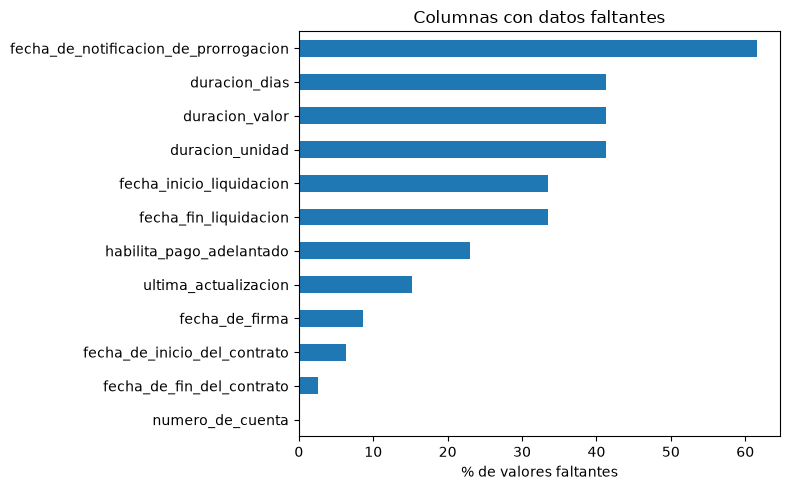

In [21]:
import matplotlib.pyplot as plt

resumen_nulos[resumen_nulos['nulos'] > 0]['pct_%'].sort_values().plot(kind='barh', figsize=(8,5))
plt.xlabel('% de valores faltantes')
plt.title('Columnas con datos faltantes')
plt.tight_layout()
plt.show()

Se dejaran los valores faltantes tal cual debido a que como no es una serie de tiempo, no tiene sentido promediar los contratos ya que cada uno es diferente, por lo que no se puede suponer

In [22]:
RUTA_SALIDA = r"C:\Users\andre\OneDrive\cosas de la universidad\Uniandes\VIII\Analitica comp\Proyecto\proyecto1-secop-agencia-logistica\02-ingenieria-datos\secop_ii_agencia_logistica_limpio.csv"
df_clean.to_csv(RUTA_SALIDA, index=False)
print(f"Guardado: {RUTA_SALIDA}  ({df_clean.shape[0]:,} filas x {df_clean.shape[1]} columnas)")

Guardado: C:\Users\andre\OneDrive\cosas de la universidad\Uniandes\VIII\Analitica comp\Proyecto\proyecto1-secop-agencia-logistica\02-ingenieria-datos\secop_ii_agencia_logistica_limpio.csv  (8,051 filas x 88 columnas)
